In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Interval
A, B = -5.0, 5.0

# Functions
def y1(x):
    return -0.5 * x + 4.0

def y2(x):
    return -0.29 * x**2 - x + 12.5

def y3(x):
    return 1.0 + 10.0 * (x + 1.0) * np.exp(-x**2)

FUNCS = {"y1": y1, "y2": y2, "y3": y3}

# True Areas
TRUE_AREAS = {"y1": 40.0, "y2": 100.83, "y3": 27.72}

In [3]:
def rectangle_rule_midpoint(f, a, b, dx_requested):
    """
    Midpoint rectangle rule.
    If dx_requested doesn't divide (b-a) exactly, we adjust dx to fit the interval.
    Returns: (area_estimate, dx_used, n_rectangles)
    """
    if dx_requested <= 0:
        raise ValueError("Δx must be > 0")

    length = b - a
    n = int(np.ceil(length / dx_requested))          # number of rectangles
    dx_used = length / n                            # adjusted width so we end exactly at b

    x_mid = a + (np.arange(n) + 0.5) * dx_used      # midpoints
    area = np.sum(f(x_mid)) * dx_used
    return area, dx_used, n




In [4]:
# INPUT: choose rectangle widths (Δx)
dx_list = [5.0, 2.0, 1.0, 0.5, 0.25, 0.1, 0.05, 0.02, 0.01, 0.005, 0.002, 0.001, 0.0005, 0.0002, 0.0001]

# Compute results
results = {name: {"dx_req": [], "dx_used": [], "n": [], "area": [], "pct_diff": []}
           for name in FUNCS}

for dx in dx_list:
    for name, f in FUNCS.items():
        area_est, dx_used, n = rectangle_rule_midpoint(f, A, B, dx)
        true_area = TRUE_AREAS[name]
        pct_diff = abs(area_est - true_area) / true_area * 100.0

        results[name]["dx_req"].append(dx)
        results[name]["dx_used"].append(dx_used)
        results[name]["n"].append(n)
        results[name]["area"].append(area_est)
        results[name]["pct_diff"].append(pct_diff)



In [5]:
# OUTPUT: tables
for name in FUNCS:
    print(f"\n{name} (true area = {TRUE_AREAS[name]})")
    print("dx_req\t dx_used\t N\t area_est\t %diff")
    for dx_req, dx_used, n, area, pd in zip(
        results[name]["dx_req"],
        results[name]["dx_used"],
        results[name]["n"],
        results[name]["area"],
        results[name]["pct_diff"]
    ):
        print(f"{dx_req:.6g}\t {dx_used:.6g}\t {n:d}\t {area:.6f}\t {pd:.6f}")




y1 (true area = 40.0)
dx_req	 dx_used	 N	 area_est	 %diff
5	 5	 2	 40.000000	 0.000000
2	 2	 5	 40.000000	 0.000000
1	 1	 10	 40.000000	 0.000000
0.5	 0.5	 20	 40.000000	 0.000000
0.25	 0.25	 40	 40.000000	 0.000000
0.1	 0.1	 100	 40.000000	 0.000000
0.05	 0.05	 200	 40.000000	 0.000000
0.02	 0.02	 500	 40.000000	 0.000000
0.01	 0.01	 1000	 40.000000	 0.000000
0.005	 0.005	 2000	 40.000000	 0.000000
0.002	 0.002	 5000	 40.000000	 0.000000
0.001	 0.001	 10000	 40.000000	 0.000000
0.0005	 0.0005	 20000	 40.000000	 0.000000
0.0002	 0.0002	 50000	 40.000000	 0.000000
0.0001	 0.0001	 100000	 40.000000	 0.000000

y2 (true area = 100.83)
dx_req	 dx_used	 N	 area_est	 %diff
5	 5	 2	 106.875000	 5.995240
2	 2	 5	 101.800000	 0.962015
1	 1	 10	 101.075000	 0.242983
0.5	 0.5	 20	 100.893750	 0.063225
0.25	 0.25	 40	 100.848437	 0.018286
0.1	 0.1	 100	 100.835750	 0.005703
0.05	 0.05	 200	 100.833938	 0.003905
0.02	 0.02	 500	 100.833430	 0.003402
0.01	 0.01	 1000	 100.833358	 0.003330
0.005	 0.0

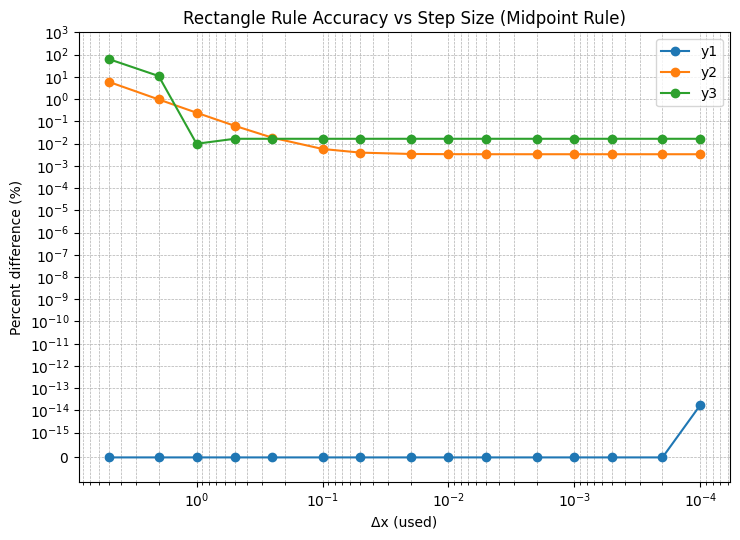

In [6]:
plt.figure(figsize=(7.5, 5.5))
for name in FUNCS:
    plt.plot(results[name]["dx_used"], results[name]["pct_diff"], marker="o", label=name)

plt.xscale("log")
plt.yscale("symlog", linthresh=1e-15)
plt.ylim(-1e-15, 1e3)
plt.gca().invert_xaxis() 
plt.xlabel("Δx (used)")
plt.ylabel("Percent difference (%)")
plt.title("Rectangle Rule Accuracy vs Step Size (Midpoint Rule)")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()